In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import networkx as nx
from torch_geometric.data import Batch

from gqa_dataset_entry import GQATorchDataset, GQATorchDataset_collate_fn
from pipeline_model_gat import PipelineModel

In [2]:
ckpt_path = "./outputdir/gat_reweight_e100/checkpoint0099.pth"

graph_top_k = 5
graph_hidden_dim = 256
graph_method = "reweight"


device = torch.device('cuda:5' if torch.cuda.is_available() else 'cpu')
print(f"Using {device}")

Using cuda:5


In [3]:
dataset = GQATorchDataset(split="val_unbiased",
                          load_vocab_flag=True,
                          graph_method=graph_method)
itos_qa = GQATorchDataset.TEXT.vocab.itos
itos_sg = type(dataset.sg_feature_lookup).SG_ENCODING_TEXT.vocab.itos
label2ans = {v: k for k, v in dataset.ans2label.items()}

finished loading the data, totally 132062 instances


In [4]:
model = PipelineModel(graph_method=graph_method,
                      graph_top_k=graph_top_k,
                      graph_hidden_dim=graph_hidden_dim)

ckpt = torch.load(ckpt_path, weights_only=False, map_location="cpu")
state = ckpt.get("model", ckpt)
model.load_state_dict(state, strict=False)
model.to(device)
model.eval()

/home/gpuhead-2/genai_project/GraphVQA/pipeline_model_gat.py:540: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  self.transformer_encoder = torch.nn.TransformerEncoder(encoder_layers, nlayers, norm=torch.nn.LayerNorm(ninp) )


PipelineModel(
  (scene_graph_encoder): GroundTruth_SceneGraph_Encoder(
    (sg_vocab_embedding): Embedding(2577, 300, padding_idx=1)
    (scene_graph_encoding_layer): MetaLayer(
      edge_model=EdgeModel(
      (edge_mlp): Sequential(
        (0): Linear(in_features=900, out_features=300, bias=True)
        (1): ReLU()
        (2): Linear(in_features=300, out_features=300, bias=True)
      )
    ),
      node_model=NodeModel(
      (node_mlp_1): Sequential(
        (0): Linear(in_features=600, out_features=300, bias=True)
        (1): ReLU()
        (2): Linear(in_features=300, out_features=300, bias=True)
      )
      (node_mlp_2): Sequential(
        (0): Linear(in_features=600, out_features=300, bias=True)
        (1): ReLU()
        (2): Linear(in_features=300, out_features=300, bias=True)
      )
    ),
      global_model=None
    )
    (graph_layer_norm): LayerNorm(300)
    (graph_builder): QuestionConditionedGraphBuilder(
      (builder): EdgeReweighting(
        (mlp_gate): 

In [25]:
def token_ids_to_words(token_ids, itos):
    pad_idx = 1
    return " ".join(itos[i] for i in token_ids.tolist() if i != pad_idx)

def sg_datum_to_nx(sg_datum, itos):
    G = nx.DiGraph()
    N = sg_datum.x.size(0)

    node_labels = {}
    for i in range(N):
        raw = token_ids_to_words(sg_datum.x[i], itos)
        parts = raw.split()
        label = parts[0] if parts else f"obj{i}"
        if len(parts) > 1:
            label += f"\n({' '.join(parts[1:])})"
        G.add_node(i, label=label)
        node_labels[i] = label
    
    edge_index = sg_datum.edge_index
    edge_attr = sg_datum.edge_attr 
    edge_labels = {}
    for e_idx in range(edge_index.size(1)):
        src = edge_index[0, e_idx].item()
        dst = edge_index[1, e_idx].item()
        if src == dst:
            continue
        rel = itos[edge_attr[e_idx, 0].item()]
        G.add_edge(src, dst, label=rel, idx=e_idx)
        edge_labels[(src, dst)] = rel
    return G, node_labels, edge_labels


def draw_scene_graph(ax, G, node_labels, edge_labels, title, node_weights=None, edge_weights=None):
    """
    Draw a NetworkX graph on ax.
    node_weights : array [N] in [0,1] – node highlight intensity (optional)
    edge_weights : dict (src,dst) → float in [0,1] – edge highlight (optional)
    """
    pos = nx.spring_layout(G, seed=42, k=1.8)
 
    # Node colours
    if node_weights is not None:
        cmap = plt.cm.YlOrRd
        node_colors = [cmap(float(node_weights[n])) for n in G.nodes()]
    else:
        node_colors = ['#AED6F1'] * len(G.nodes())
 
    # Edge colours / widths
    edges = list(G.edges())
    if edge_weights and edges:
        edge_colors = [edge_weights.get(e, 0.0) for e in edges]
        edge_widths  = [1.0 + 3.0 * edge_weights.get(e, 0.0) for e in edges]
        edge_colors  = [plt.cm.Reds(v) for v in edge_colors]
    else:
        edge_colors = ['#555555'] * len(edges)
        edge_widths  = [1.0] * len(edges)
 
    nx.draw_networkx_nodes(G, pos, ax=ax, node_color=node_colors,
                           node_size=900, alpha=0.9)
    nx.draw_networkx_labels(G, pos, labels=node_labels, ax=ax,
                            font_size=7, font_weight='bold')
    nx.draw_networkx_edges(G, pos, ax=ax, edge_color=edge_colors,
                           width=edge_widths, arrows=True,
                           arrowsize=15, connectionstyle='arc3,rad=0.1',
                           min_source_margin=20, min_target_margin=20)
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, ax=ax,
                                 font_size=6, label_pos=0.35)
    ax.set_title(title, fontsize=9, pad=4)
    ax.axis('off')


def collect_gat_attention(model: PipelineModel):
    store = {}
    hooks = []

    for i, conv in enumerate(model.gat_seq.convs):
        def make_hook(idx):
            def hook(module, input, output):
                if module._alpha is not None:
                    store[idx] = module._alpha.detach().cpu()
                else:
                    store[idx] = None
            return hook
        hooks.append(conv.register_forward_hook(make_hook(i)))
    
    return hooks, store

def remove_hooks(hooks):
    for h in hooks:
        h.remove()

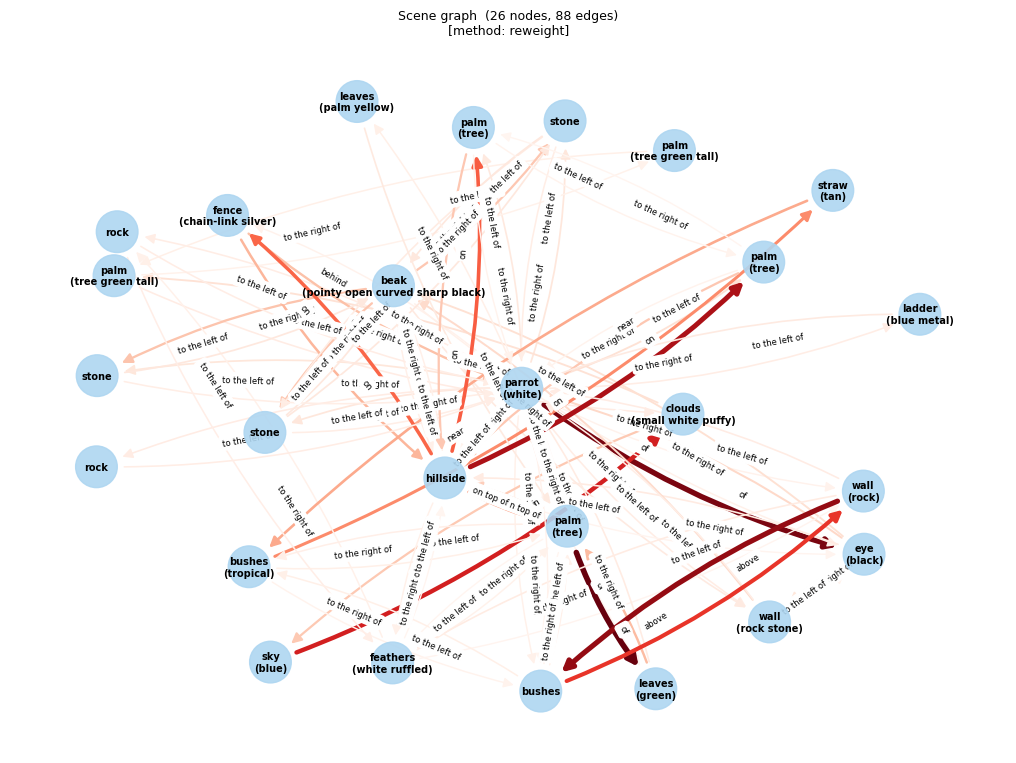

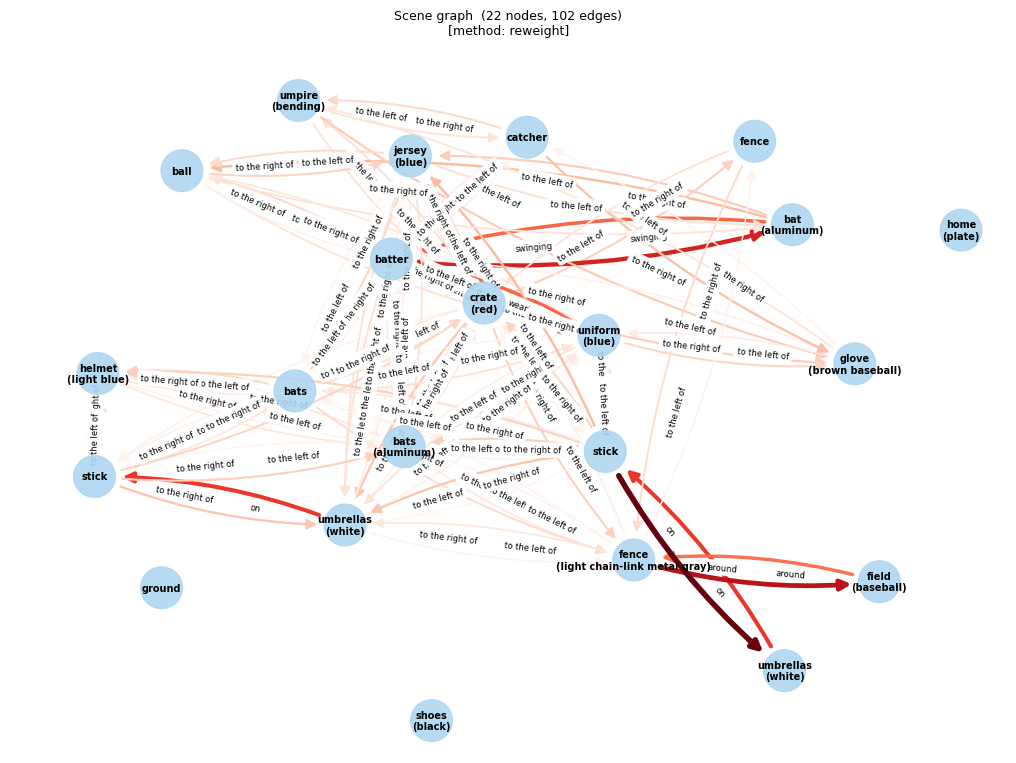

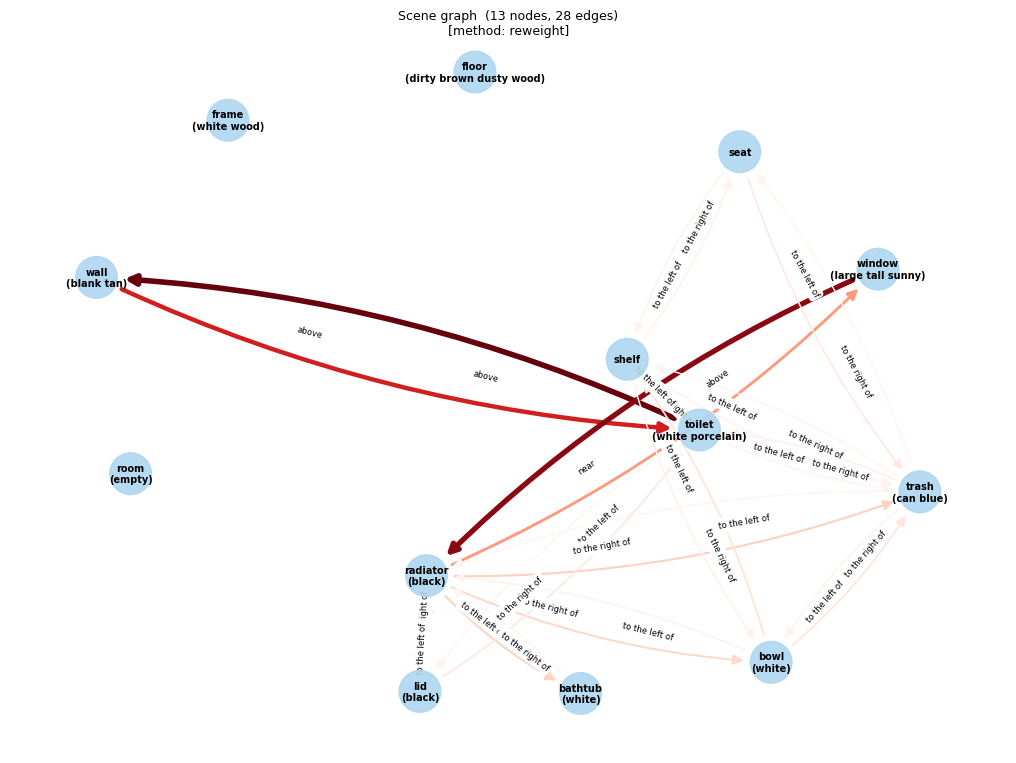

In [ ]:
NUM_SAMPLES = 3
SAMPLE_OFFSET = 0

for sample_i in range(NUM_SAMPLES):
    idx = SAMPLE_OFFSET + sample_i
    item = dataset[idx]
    questionID, q_tokens, sg_datum, prog_tokens, fa_tokens, sa_label, types = item

    batch = GQATorchDataset_collate_fn([item])
    qID_b, questions_b, sg_b, programs_b, fa_b, sa_label_b, types_b = batch

    questions_b = questions_b.to(device)
    sg_b        = sg_b.to(device)
    programs_b  = programs_b.to(device)

    hooks, attn_score = collect_gat_attention(model)
    with torch.no_grad():
        programs_out, sa_logits = model(
            questions=questions_b,
            gt_scene_graphs=sg_b,
            programs_input=programs_b[:-1],
            full_answers_input=None,
            SAMPLE_FLAG=False,
        )
    remove_hooks(hooks)

    pred_ans = label2ans[sa_logits.argmax(dim=-1).item()]
    true_ans = label2ans[sa_label]

    q_str = " ".join(q_tokens)

    G, node_labels, edge_labels_dict = sg_datum_to_nx(sg_datum, itos_sg)
    N = sg_datum.x.size(0)
    E = sg_datum.edge_index.size(1)

    # Build ordered edge label list for heatmap (all edges incl self-loops)
    edge_label_list = []
    for e in range(E):
        s = sg_datum.edge_index[0, e].item()
        d = sg_datum.edge_index[1, e].item()
        rel = itos_sg[sg_datum.edge_attr[e, 0].item()]
        edge_label_list.append(f"{node_labels.get(s, s)}→{node_labels.get(d, d)}: {rel}")

    n_gat = len(attn_score)
    fig = plt.figure(figsize=(5 * max(n_gat, 2), 12), constrained_layout=True)


    gs = fig.add_gridspec(2, max(n_gat, 2), height_ratios=[1.6, 1])

    ax_sg = fig.add_subplot(gs[0, :n_gat // 2]) 


    ew_dict = {}
    if graph_method == 'reweight' and hasattr(
            model.scene_graph_encoder, 'graph_builder'):
        # Re-run just the graph builder to get edge weights for this sample
        with torch.no_grad():
            q_enc  = model.question_encoder(questions_b)
            q_sum  = q_enc[0]  # [1, d_q]
            x_emb  = model.scene_reweightgraph_encoder.sg_vocab_embedding(sg_b.x)
            x_sum  = x_emb.sum(dim=-2)
            e_emb  = model.scene_graph_encoder.sg_vocab_embedding(sg_b.edge_attr)
            e_emb[sg_b.added_sym_edge, :, :] *= -1
            e_sum  = e_emb.sum(dim=-2)
            ei     = sg_b.edge_index
            eb     = sg_b.batch[ei[0]]
            ew     = model.scene_graph_encoder.graph_builder.builder(
                h=x_sum, e=e_sum, q=q_sum,
                edge_index=ei, edge_batch=eb
            ).cpu().numpy()   # [E]
        # map to (src,dst) for the nx graph
        for e_idx in range(E):
            s = sg_datum.edge_index[0, e_idx].item()
            d = sg_datum.edge_index[1, e_idx].item()
            if s != d:
                ew_dict[(s, d)] = float(ew[e_idx])
        # normalise to [0,1]
        if ew_dict:
            mn, mx = min(ew_dict.values()), max(ew_dict.values())
            ew_dict = {k: (v - mn) / (mx - mn + 1e-9) for k, v in ew_dict.items()}

    draw_scene_graph(ax_sg, G, node_labels, edge_labels_dict,
                        title=f"Scene graph  ({N} nodes, {G.number_of_edges()} edges)\n"
                            f"[method: {graph_method}]",
                        edge_weights=ew_dict if ew_dict else None)

In [9]:
params = dict(model.named_children())
params.keys()

dict_keys(['scene_graph_encoder', 'text_vocab_embedding', 'question_encoder', 'program_decoder', 'gat_seq', 'graph_global_attention_pooling', 'full_answer_decoder', 'logit_fc'])

In [ ]:
params["gat_seq"].convs[0]